In [18]:
#1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully")

All libraries imported successfully


In [19]:
#2. Read CSV
df = pd.read_csv("data.csv")

df.head()

,Duration,Date,Pulse,Maxpulse,Calories
0,60,'2020/12/01',110,130,409.1
1,60,'2020/12/02',117,145,479.0
2,60,'2020/12/03',103,135,340.0
3,45,'2020/12/04',109,175,282.4
4,45,'2020/12/05',117,148,406.0


In [20]:
#3. Understand the dataset
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Duration  32 non-null     int64  
 1   Date      31 non-null     object 
 2   Pulse     32 non-null     int64  
 3   Maxpulse  32 non-null     int64  
 4   Calories  30 non-null     float64
dtypes: float64(1), int64(3), object(1)
memory usage: 1.4+ KB


,Duration,Pulse,Maxpulse,Calories
count,32.000000,32.000000,32.000000,30.000000
mean,68.437500,103.500000,128.500000,304.680000
std,70.039591,7.832933,12.998759,66.003779
min,30.000000,90.000000,101.000000,195.100000
25%,60.000000,100.000000,120.000000,250.700000
50%,60.000000,102.500000,127.500000,291.200000
75%,60.000000,106.500000,132.250000,343.975000
max,450.000000,130.000000,175.000000,479.000000


In [21]:
#4. Find missing values
df.isnull().sum()
#Percentage of missing values:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

Calories    6.250
Date        3.125
Duration    0.000
Pulse       0.000
Maxpulse    0.000
dtype: float64

In [22]:
#5. Handle missing values
#For numeric columns:

numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].median()
)

#For text columns:

text_columns = df.select_dtypes(include="object").columns

for column in text_columns:
    df[column] = df[column].fillna("Unknown")

In [23]:
#Then verify:

df.isnull().sum()

Duration    0
Date        0
Pulse       0
Maxpulse    0
Calories    0
dtype: int64

In [24]:
#6. Remove duplicate rows
df.duplicated().sum()

#Then:

df = df.drop_duplicates()

In [26]:
#Step 1 — Clean the Date column

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print(df.isnull().sum())

Duration    0
Date        2
Pulse       0
Maxpulse    0
Calories    0
dtype: int64


In [27]:
#Step 2 — Handle missing values
#You have missing values in Date and Calories.
#For Calories, use the median:

df["Calories"] = df["Calories"].fillna(df["Calories"].median())

#For Date, we'll remove the row because we cannot reliably invent the missing date:

df = df.dropna(subset=["Date"])
#Checking again:

print(df.isnull().sum())

Duration    0
Date        0
Pulse       0
Maxpulse    0
Calories    0
dtype: int64


In [28]:
#Step 3 — Remove duplicate rows
print("Duplicate rows:", df.duplicated().sum())
#Then:
df = df.drop_duplicates()

Duplicate rows: 0


In [29]:
#Step 4 — Filter rows
#Duration greater than 60
df[df["Duration"] > 60]
#Pulse greater than 100
df[df["Pulse"] > 100]
#Calories greater than 300
df[df["Calories"] > 300]

#You can also combine conditions:

df[(df["Duration"] > 60) & (df["Calories"] > 300)]

,Duration,Date,Pulse,Maxpulse,Calories


In [30]:
#Step 5 — Create new columns
#This is one of your assignment requirements.
#Create Pulse Difference
df["Pulse_Difference"] = df["Maxpulse"] - df["Pulse"]

#Check:
df.head()

,Duration,Date,Pulse,Maxpulse,Calories,Pulse_Difference
0,60,2020-12-01,110,130,409.1,20
1,60,2020-12-02,117,145,479.0,28
2,60,2020-12-03,103,135,340.0,32
3,45,2020-12-04,109,175,282.4,66
4,45,2020-12-05,117,148,406.0,31


In [31]:
#Create an intensity category
df["Intensity"] = np.where(
    df["Pulse"] >= 100,
    "High",
    "Normal"
)

#Check:

df[["Pulse", "Intensity"]].head(10)

,Pulse,Intensity
0,110,High
1,117,High
2,103,High
3,109,High
4,117,High
5,102,High
6,110,High
7,104,High
8,109,High
9,98,Normal


In [32]:
#Step 6 — Pandas calculations
#Average duration
df["Duration"].mean()

#Average pulse
df["Pulse"].mean()

#Average calories
df["Calories"].mean()

#Maximum calories
df["Calories"].max()

#Minimum calories
df["Calories"].min()

#Total calories
df["Calories"].sum()

np.float64(8940.099999999999)

In [33]:
#Step 7 — Group By
#Now demonstrate groupby().

df.groupby("Intensity")["Calories"].mean()

Intensity
High      325.577273
Normal    253.914286
Name: Calories, dtype: float64

In [34]:
#Step 8 — Sort the data
#Highest calories first:

df.sort_values("Calories", ascending=False).head(10)

#Highest pulse first:

df.sort_values("Pulse", ascending=False).head(10)

,Duration,Date,Pulse,Maxpulse,Calories,Pulse_Difference,Intensity
23,60,2020-12-23,130,101,300.0,-29,High
4,45,2020-12-05,117,148,406.0,31,High
1,60,2020-12-02,117,145,479.0,28,High
6,60,2020-12-07,110,136,374.0,26,High
0,60,2020-12-01,110,130,409.1,20,High
8,30,2020-12-09,109,133,195.1,24,High
3,45,2020-12-04,109,175,282.4,66,High
21,60,2020-12-21,108,131,364.2,23,High
13,60,2020-12-13,106,128,345.3,22,High
24,45,2020-12-24,105,132,246.0,27,High


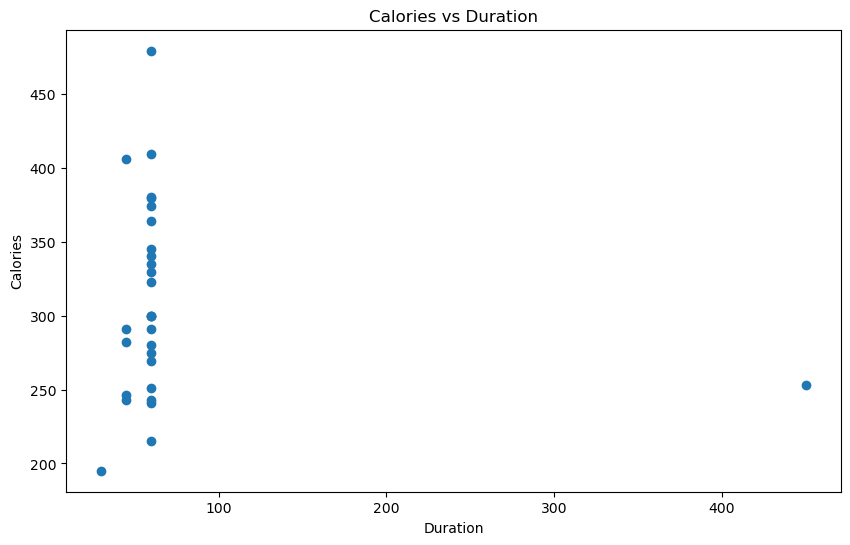

In [35]:
#Step 9 — Matplotlib visualization
#Calories by Duration
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Duration"],
    df["Calories"]
)

plt.title("Calories vs Duration")
plt.xlabel("Duration")
plt.ylabel("Calories")

plt.show()

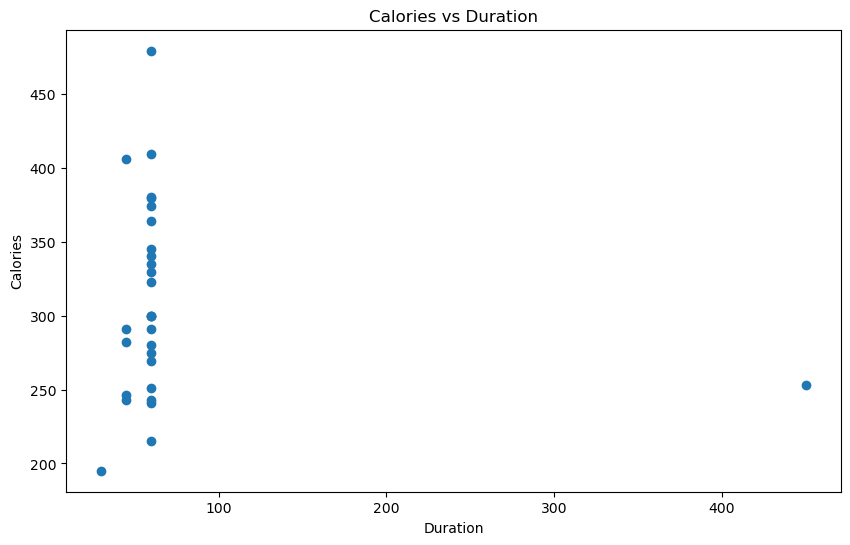

In [36]:
#Step 9 — Matplotlib visualization
#Calories by Duration
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Duration"],
    df["Calories"]
)

plt.title("Calories vs Duration")
plt.xlabel("Duration")
plt.ylabel("Calories")

plt.show()

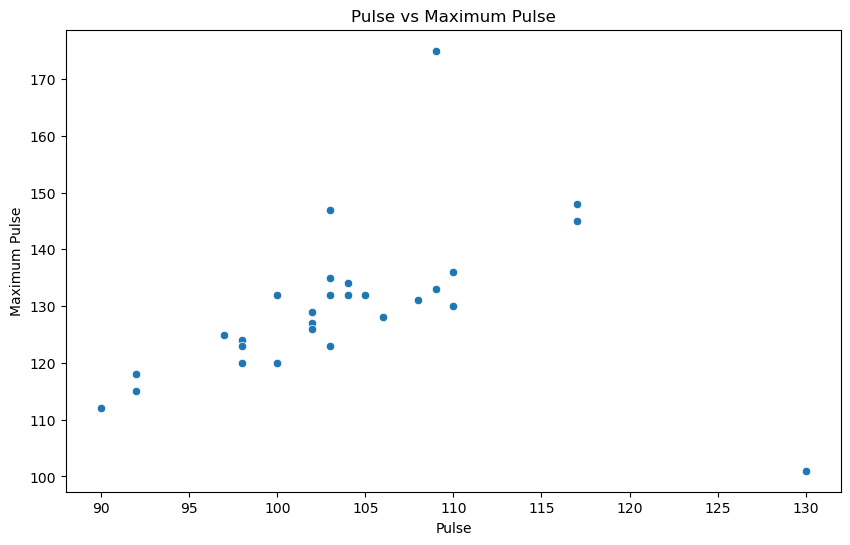

In [37]:
#Step 11 — Pulse vs Maxpulse
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Pulse",
    y="Maxpulse"
)

plt.title("Pulse vs Maximum Pulse")
plt.xlabel("Pulse")
plt.ylabel("Maximum Pulse")

plt.show()

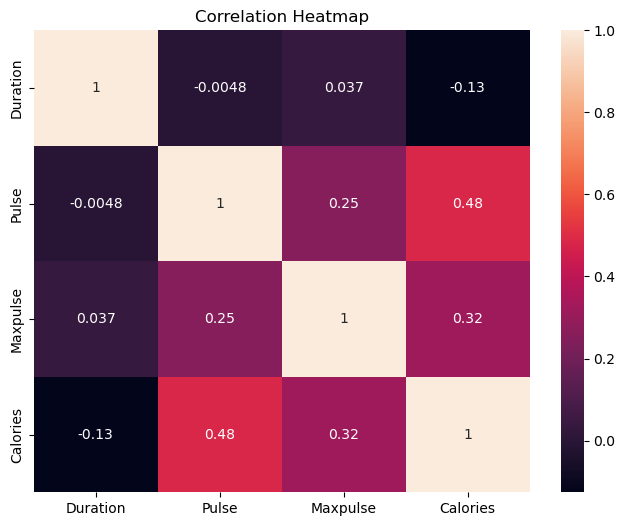

In [38]:
#Step 12 — Correlation heatmap
#This is a very good visualization for your assignment.

plt.figure(figsize=(8, 6))

sns.heatmap(
    df[["Duration", "Pulse", "Maxpulse", "Calories"]].corr(),
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

In [39]:
#Step 13 — Save the cleaned dataset
#Finally:

df.to_csv("cleaned_data.csv", index=False)